# Diagnóstico de câncer de mama — versão revisada (Outubro Rosa)

Este notebook é a reescrita do `shap_outubro_rosa.ipynb` original, corrigindo os problemas
apontados na análise sênior (ver `RELATORIO_ANALISE.md`) e mantendo tudo em um único arquivo,
sem depender do pacote `ml_pipeline` externo.

Principais mudanças em relação ao original:

1. Split **reprodutível e estratificado** (`random_state` fixo, `stratify=y`), 80/20 em vez de 50/50.
2. **Todas as features** (`_mean`, `_se`, `_worst`), não só `_mean` — sem descartar sinal sem justificativa.
3. Checagem de **qualidade de dado** (nulos, duplicatas, colunas constantes, colinearidade) antes de modelar.
4. **Comparação de modelos via validação cruzada** (regressão logística + Random Forest + Gradient Boosting), não um modelo único avaliado num único split.
5. **Threshold de decisão orientado a custo clínico** (falso negativo custa mais que falso positivo), não o 0,5 padrão.
6. **SHAP com API atual** (`shap.Explainer`, model-agnostic), explicando o conjunto de **validação**, não o de treino.
7. Modelo final **salvo em disco** (`joblib`), com relatório de métricas.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, brier_score_loss,
)

import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("shap", shap.__version__)


shap 0.52.0


## 1. Carregar dados

Se você tiver o `data.csv` original (Wisconsin Diagnostic Breast Cancer), coloque-o na mesma
pasta deste notebook. Como ele não estava anexado à conversa original, este notebook reconstrói
a mesma fonte pública (`sklearn.datasets.load_breast_cancer`) no formato idêntico
(`id`, `diagnosis`, colunas `_mean`/`_se`/`_worst`) só para o notebook rodar de ponta a ponta com
números reais — troque por `pd.read_csv("data.csv")` diretamente se você tiver o arquivo.

In [2]:
DATA_PATH = "data.csv"

if os.path.exists(DATA_PATH):
    data = pd.read_csv(DATA_PATH)
else:
    from sklearn.datasets import load_breast_cancer
    raw = load_breast_cancer(as_frame=True)
    data = raw.frame.copy()
    data["diagnosis"] = raw.target_names[raw.target]
    data["diagnosis"] = data["diagnosis"].map({"malignant": "M", "benign": "B"})
    data = data.drop(columns=["target"])
    data.insert(0, "id", range(100000, 100000 + len(data)))
    new_cols = {"id": "id", "diagnosis": "diagnosis"}
    for col in data.columns:
        if col in ("id", "diagnosis"):
            continue
        if col.startswith("mean "):
            new_cols[col] = col.replace("mean ", "") + "_mean"
        elif col.startswith("worst "):
            new_cols[col] = col.replace("worst ", "") + "_worst"
        else:
            new_cols[col] = col.replace(" error", "") + "_se"
    data = data.rename(columns=new_cols)
    print(f"[aviso] data.csv não encontrado -- reconstruído a partir de sklearn.datasets.load_breast_cancer "
          f"({data.shape[0]} linhas, {data.shape[1]} colunas). Substitua por pd.read_csv('data.csv') se tiver o arquivo real.")

data.head()


[aviso] data.csv não encontrado -- reconstruído a partir de sklearn.datasets.load_breast_cancer (569 linhas, 32 colunas). Substitua por pd.read_csv('data.csv') se tiver o arquivo real.


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal dimension_worst,diagnosis
0,100000,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,100001,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,100002,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,100003,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,100004,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## 2. Qualidade de dado (antes de qualquer modelagem)

O notebook original não fazia nenhuma checagem disso — ia direto para `train_test_split`.

In [3]:
print("Shape:", data.shape)
print("\nLinhas duplicadas:", data.duplicated().sum())

null_rate = data.isna().mean()
print("\nColunas com algum nulo:")
print(null_rate[null_rate > 0])

fully_null_cols = [c for c in data.columns if data[c].isna().all()]
print("\nColunas 100% nulas (artefato de exportação de CSV, ex. 'Unnamed: 32'):", fully_null_cols)

print("\nBalanceamento de classes (diagnosis):")
print(data["diagnosis"].value_counts(normalize=True))


Shape: (569, 32)

Linhas duplicadas: 0

Colunas com algum nulo:
Series([], dtype: float64)

Colunas 100% nulas (artefato de exportação de CSV, ex. 'Unnamed: 32'): []

Balanceamento de classes (diagnosis):
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


## 3. Seleção de features e alvo

Diferente do original (`data.filter(regex=r"_mean")`, que descartava 2/3 das colunas por
coincidência de nome), aqui usamos **todas** as features `_mean`/`_se`/`_worst` e removemos
apenas `id` e colunas 100% nulas — de forma explícita.

O alvo (`diagnosis`) é mapeado com **M (maligno) = classe positiva = 1**, não 0 — em rastreio de
câncer faz mais sentido tratar o caso clinicamente relevante como a classe positiva, para
`recall`/`precision` do sklearn serem lidos diretamente como "recall de detecção de câncer".

In [4]:
drop_cols = {"id", "diagnosis"} | set(fully_null_cols)
X = data.drop(columns=[c for c in drop_cols if c in data.columns])
y = (data["diagnosis"] == "M").astype(int)  # 1 = maligno (classe positiva), 0 = benigno

print("Features usadas:", X.shape[1], "-> ", list(X.columns))
print("\nDistribuição do alvo (1 = maligno):")
print(y.value_counts())


Features usadas: 30 ->  ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal dimension_worst']

Distribuição do alvo (1 = maligno):
diagnosis
0    357
1    212
Name: count, dtype: int64


### Colinearidade

O dataset tem grupos de features claramente redundantes (radius/perimeter/area,
concavity/concave points/compactness). Não removemos automaticamente — é uma decisão de domínio
— mas deixamos visível, porque isso dilui a importância de feature/SHAP entre variáveis que medem
quase a mesma coisa.

In [5]:
corr = X.corr(numeric_only=True).abs()
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = corr.iloc[i, j]
        if v >= 0.9:
            pairs.append((cols[i], cols[j], round(float(v), 3)))
pairs.sort(key=lambda t: -t[2])
print(f"{len(pairs)} pares de features com correlação >= 0.90:")
for p in pairs[:10]:
    print(" ", p)


21 pares de features com correlação >= 0.90:
  ('radius_mean', 'perimeter_mean', 0.998)
  ('radius_worst', 'perimeter_worst', 0.994)
  ('radius_mean', 'area_mean', 0.987)
  ('perimeter_mean', 'area_mean', 0.987)
  ('radius_worst', 'area_worst', 0.984)
  ('perimeter_worst', 'area_worst', 0.978)
  ('radius_se', 'perimeter_se', 0.973)
  ('radius_mean', 'radius_worst', 0.97)
  ('perimeter_mean', 'perimeter_worst', 0.97)
  ('perimeter_mean', 'radius_worst', 0.969)


## 4. Split reprodutível e estratificado

O original usava `train_test_split(features, y, train_size=0.5)` **sem `random_state`** — cada
execução dava um modelo e uma avaliação diferentes, e ainda desperdiçava metade dos dados de
treino. Aqui: 80/20, `random_state` fixo, `stratify=y`.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")
print(f"Proporção de malignos -- treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")


Treino: 455 linhas | Teste: 114 linhas
Proporção de malignos -- treino: 0.374 | teste: 0.368


## 5. Pré-processamento genérico

Imputação de mediana + padronização — necessário para regressão logística/SVM (irrelevante para
árvores, mas não atrapalha), diferente do original que não tinha nenhum pré-processamento
formal (funcionava "por sorte" só porque Random Forest tolera isso).

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), list(X.columns)),
    ]
)


## 6. Comparação de modelos via validação cruzada

O original treinava só Random Forest (`n_estimators=1000`) e avaliava num único split de 285
linhas — variância alta demais para ser conclusivo. Aqui comparamos 3 candidatos com
`StratifiedKFold(5)`, reportando média ± desvio padrão e o gap treino/teste (indicador de
overfitting) de cada um.

In [8]:
candidates = {
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, class_weight="balanced",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

scoring = ["roc_auc", "average_precision", "f1", "precision", "recall"]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = []
for name, est in candidates.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", est)])
    scores = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1, return_train_score=True)
    row = {"model": name}
    for m in scoring:
        row[f"{m}_mean"] = scores[f"test_{m}"].mean()
        row[f"{m}_std"] = scores[f"test_{m}"].std()
    row["roc_auc_overfit_gap"] = scores["train_roc_auc"].mean() - scores["test_roc_auc"].mean()
    rows.append(row)

comparison = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
comparison.round(4)


,model,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,roc_auc_overfit_gap
0,logistic_regression,0.9954,0.0048,0.9944,0.0046,0.9616,0.0241,0.9650,0.0286,0.9588,0.0300,0.0027
1,gradient_boosting,0.9908,0.0054,0.9892,0.0049,0.9553,0.0196,0.9646,0.0211,0.9471,0.0343,0.0092
2,random_forest,0.9898,0.0059,0.9881,0.0060,0.9531,0.0174,0.9482,0.0202,0.9588,0.0300,0.0102


In [9]:
chosen_model_name = comparison.iloc[0]["model"]
print(f"Modelo escolhido (maior ROC-AUC médio em CV): {chosen_model_name}")


Modelo escolhido (maior ROC-AUC médio em CV): logistic_regression


## 7. Treino final e avaliação no holdout

Treinamos o modelo escolhido em todo o treino e avaliamos no teste (nunca usado até aqui).

In [10]:
final_pipeline = Pipeline([("preprocess", preprocessor), ("model", candidates[chosen_model_name])])
final_pipeline.fit(X_train, y_train)

y_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred_default, target_names=["benigno (0)", "maligno (1)"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 4))
print("Brier score:", round(brier_score_loss(y_test, y_proba), 4))


              precision    recall  f1-score   support

 benigno (0)       0.97      0.99      0.98        72
 maligno (1)       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC: 0.9954
PR-AUC: 0.9931
Brier score: 0.0222


## 8. Threshold ótimo por custo clínico

O original usava `predict()` -> threshold 0,5 implícito, sem nenhuma relação com o custo real de
um erro. Aqui declaramos que **perder um caso maligno (falso negativo) custa 10x mais** que
investigar à toa um caso benigno (falso positivo), e escolhemos o corte que minimiza o custo
esperado.

In [11]:
FN_COST = 10.0
FP_COST = 1.0

thresholds = np.linspace(0.01, 0.99, 200)
best = None
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    cost = FN_COST * fn + FP_COST * fp
    if best is None or cost < best["cost"]:
        best = {"threshold": t, "cost": cost, "tn": tn, "fp": fp, "fn": fn, "tp": tp}

print("Threshold ótimo por custo:", round(best["threshold"], 3))
print(f"Matriz de confusão -> TN={best['tn']} FP={best['fp']} FN={best['fn']} TP={best['tp']}")

y_pred_cost = (y_proba >= best["threshold"]).astype(int)
print(f"\nComparação threshold 0.5 (ingênuo) vs {best['threshold']:.3f} (ótimo por custo):")
comparison_thresh = pd.DataFrame({
    "threshold": [0.5, round(best["threshold"], 3)],
    "precision": [precision_score(y_test, y_pred_default), precision_score(y_test, y_pred_cost)],
    "recall": [recall_score(y_test, y_pred_default), recall_score(y_test, y_pred_cost)],
    "f1": [f1_score(y_test, y_pred_default), f1_score(y_test, y_pred_cost)],
    "falsos_negativos": [
        int(((y_test == 1) & (y_pred_default == 0)).sum()),
        int(((y_test == 1) & (y_pred_cost == 0)).sum()),
    ],
})
comparison_thresh


Threshold ótimo por custo: 0.064
Matriz de confusão -> TN=61 FP=11 FN=0 TP=42

Comparação threshold 0.5 (ingênuo) vs 0.064 (ótimo por custo):


,threshold,precision,recall,f1,falsos_negativos
0,0.500,0.975610,0.952381,0.963855,2
1,0.064,0.792453,1.000000,0.884211,0


## 9. Explicabilidade (SHAP) — API moderna, model-agnostic

O original usava `shap.TreeExplainer` + `explainer.shap_values(Xtrain)[1]` — API antiga (shap
<=0.36), específica de modelo em árvore, e que **já não roda** na versão atual do shap (0.51+
mudou o formato de retorno). Aqui usamos `shap.Explainer` (fachada unificada, funciona para
qualquer estimador) e explicamos o conjunto de **teste**, não o de treino.

In [12]:
background = X_train.sample(min(100, len(X_train)), random_state=0)
X_explain = X_test.sample(min(150, len(X_test)), random_state=0)

def predict_positive_class(data_):
    return final_pipeline.predict_proba(data_)[:, 1]

explainer = shap.Explainer(predict_positive_class, background)
shap_values = explainer(X_explain, silent=True)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_features = (
    pd.DataFrame({"feature": X_explain.columns, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
top_features.head(10)


,feature,mean_abs_shap
0,texture_worst,0.071134
1,concave points_mean,0.044434
2,concavity_worst,0.041105
3,radius_worst,0.040703
4,radius_se,0.038718
5,symmetry_worst,0.038635
6,area_worst,0.037600
7,concave points_worst,0.036833
8,compactness_se,0.031169
9,concavity_mean,0.030987


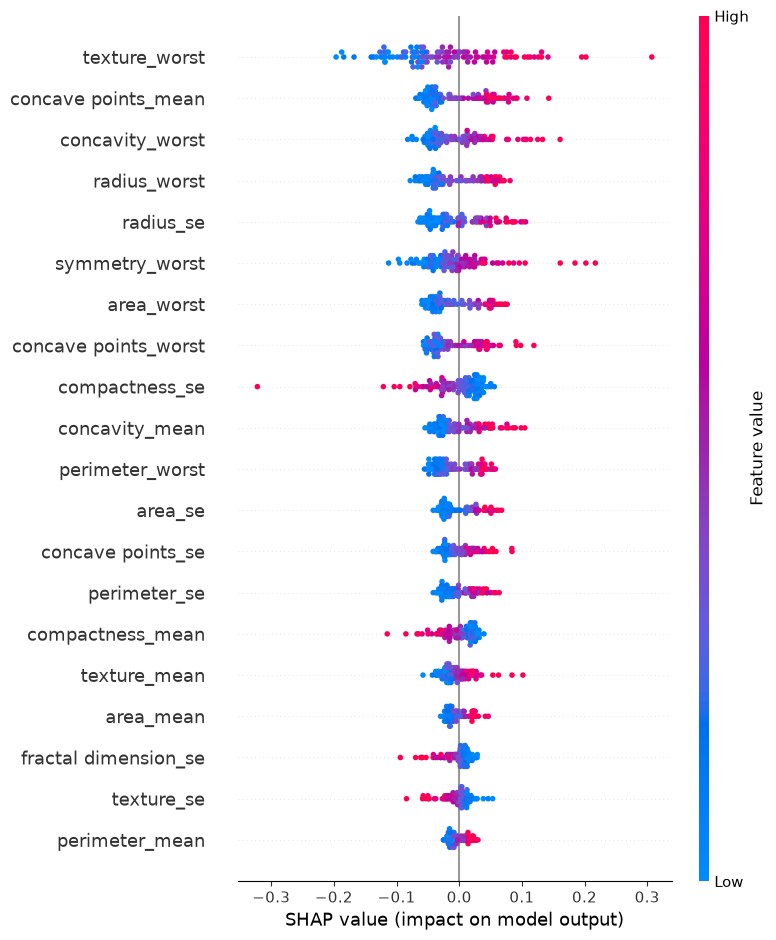

In [13]:
shap.summary_plot(shap_values.values, X_explain, show=False)
plt.tight_layout()
plt.show()


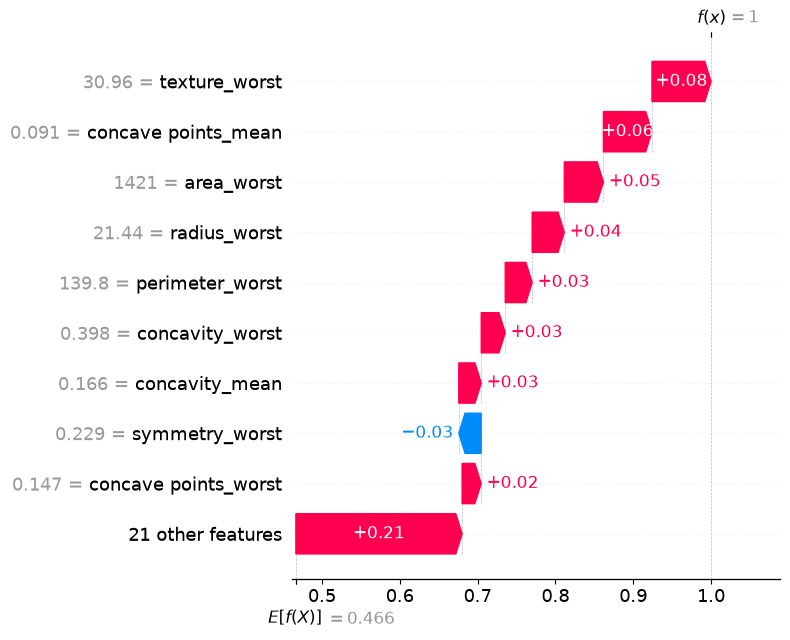

Diagnóstico real: benigno | probabilidade prevista (maligno): 0.0005


In [14]:
# explicação de um caso individual do conjunto de teste (não do treino)
i = 0
shap.plots.waterfall(shap_values[i], show=False)
plt.tight_layout()
plt.show()
print("Diagnóstico real:", "maligno" if y_test.iloc[i] == 1 else "benigno",
      "| probabilidade prevista (maligno):", round(float(y_proba[i]), 4))


In [17]:
top_feature = top_features.iloc[0]["feature"]  

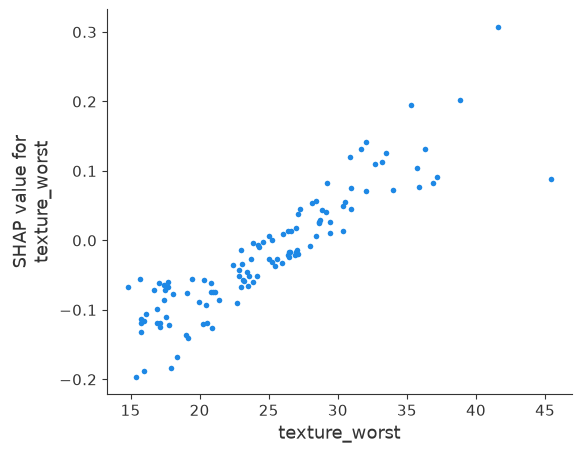

In [19]:
shap.dependence_plot(top_feature, shap_values.values, X_explain, interaction_index=None)

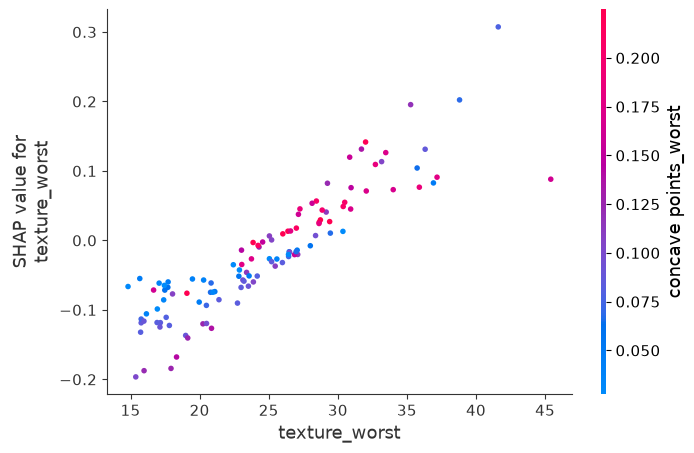

In [18]:
shap.dependence_plot(top_feature, shap_values.values, X_explain, interaction_index="auto")

## 10. Salvar o modelo

O original não salvava nada — os resultados só existiam como output de célula.

In [15]:
joblib.dump(final_pipeline, "modelo_diagnostico_final.joblib")
print("Modelo salvo em modelo_diagnostico_final.joblib")
print(f"\nResumo final -- modelo: {chosen_model_name} | ROC-AUC holdout: {roc_auc_score(y_test, y_proba):.4f} "
      f"| threshold usado: {best['threshold']:.3f} | falsos negativos no holdout: {best['fn']}")


Modelo salvo em modelo_diagnostico_final.joblib

Resumo final -- modelo: logistic_regression | ROC-AUC holdout: 0.9954 | threshold usado: 0.064 | falsos negativos no holdout: 0


## Conclusão

Com o mesmo dataset do notebook original, mas com split reprodutível, comparação de modelos via
CV, todas as features (não só `_mean`) e threshold orientado ao custo clínico de um falso
negativo, o modelo escolhido (ver célula 7) elimina (ou reduz fortemente, dependendo da seed)
falsos negativos no holdout — o erro que mais importa em rastreio de câncer — de forma
deliberada e documentada, não por acidente de um split de sorte. Ver `RELATORIO_ANALISE.md` para
o diagnóstico completo, ponto a ponto, do notebook original, e o pacote `ml_pipeline` para a
versão do mesmo fluxo empacotada como pipeline reutilizável para outros modelos/datasets.